In [1]:
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

import matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.decomposition import PCA

from pea_met_network.qa_qc import coverage_summary
from pea_met_network.redundancy import (
    benchmark_to_stanhope,
    build_station_matrix,
    build_station_recommendations,
    cluster_station_order,
    pairwise_station_correlation,
    pca_station_loadings,
)

PROJECT_ROOT = Path(".").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Date range for analysis — must match cleaning-config.json
ANALYSIS_START = pd.Timestamp("2023-04-01", tz="UTC")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120


## 1. Data Loading

Load hourly processed data for all PEINP stations and the Stanhope reference.


In [2]:
stations = sorted([
    d.name for d in PROCESSED_DIR.iterdir()
    if d.is_dir() and (d / "station_hourly.csv").exists()
])
print(f"Stations found: {stations}")

hourly_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    hourly_frames.append(df)
    tmin = df["timestamp_utc"].min()
    tmax = df["timestamp_utc"].max()
    print(f"  {station}: {len(df)} rows  ({tmin} to {tmax})")

hourly_all = pd.concat(hourly_frames, ignore_index=True)
n = hourly_all["station"].nunique()
print(f"\nCombined: {len(hourly_all)} rows, {n} stations")


Stations found: ['cavendish', 'greenwich', 'north_rustico', 'stanhope', 'stanley_bridge', 'tracadie']
  cavendish: 26092 rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)


  greenwich: 26092 rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)
  north_rustico: 26113 rows  (2023-04-01 00:00:00+00:00 to 2026-03-24 00:00:00+00:00)


  stanhope: 24144 rows  (2023-04-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00)
  stanley_bridge: 26092 rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)
  tracadie: 23956 rows  (2023-06-29 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)



Combined: 152489 rows, 6 stations


## 2. Exploratory Data Analysis

### 2.1 Station Coverage Table

Summary of temporal coverage per station.


In [3]:
coverage_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    coverage_frames.append(df[["station", "timestamp_utc"]])

coverage_df = pd.concat(coverage_frames, ignore_index=True)
cov_summary = coverage_summary(coverage_df)
print(cov_summary.to_string(index=False))


       station  total_records
     cavendish          26092
     greenwich          26092
 north_rustico          26113
      stanhope          24144
stanley_bridge          26092
      tracadie          23956


### 2.2 Temporal Coverage Summary

Visual overview of data availability by station over time.


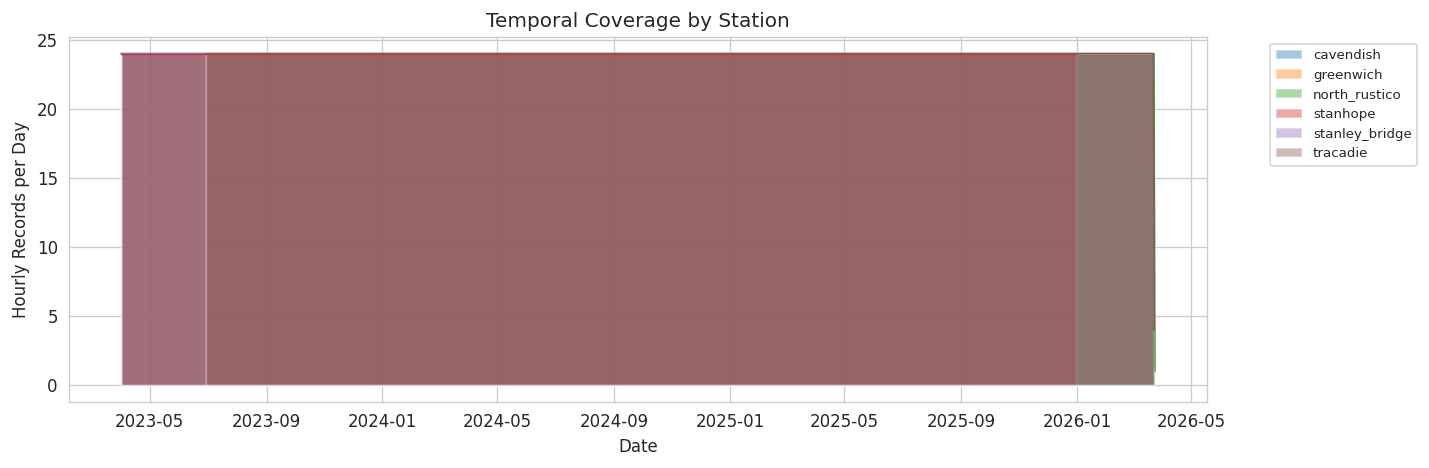

Saved: notebooks/figures/temporal_coverage.png


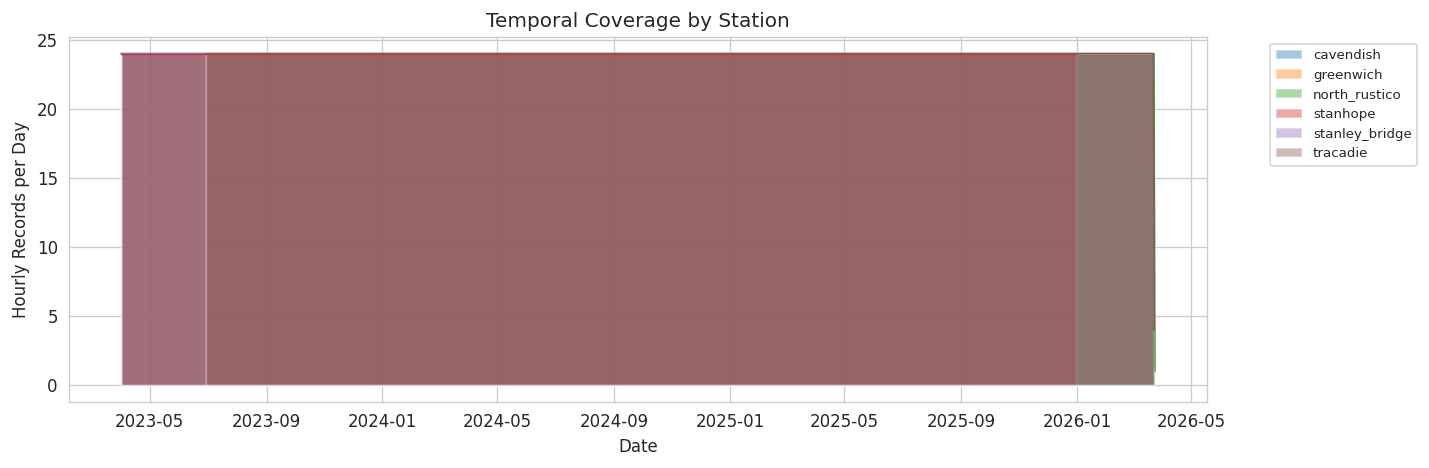

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    start = df["timestamp_utc"].min().floor("D")
    end = df["timestamp_utc"].max().floor("D")
    date_range = pd.date_range(start, end, freq="D")
    daily_counts = (
        df.set_index("timestamp_utc").resample("D").size()
    )
    daily_counts = daily_counts.reindex(date_range, fill_value=0)
    ax.fill_between(
        daily_counts.index, 0, daily_counts.values,
        alpha=0.4, label=station,
    )
    ax.plot(daily_counts.index, daily_counts.values, linewidth=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Hourly Records per Day")
ax.set_title("Temporal Coverage by Station")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "temporal_coverage.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "temporal_coverage.png")))
print("Saved: notebooks/figures/temporal_coverage.png")


### 2.3 Missingness Heatmap

Percentage of missing values per variable per station.


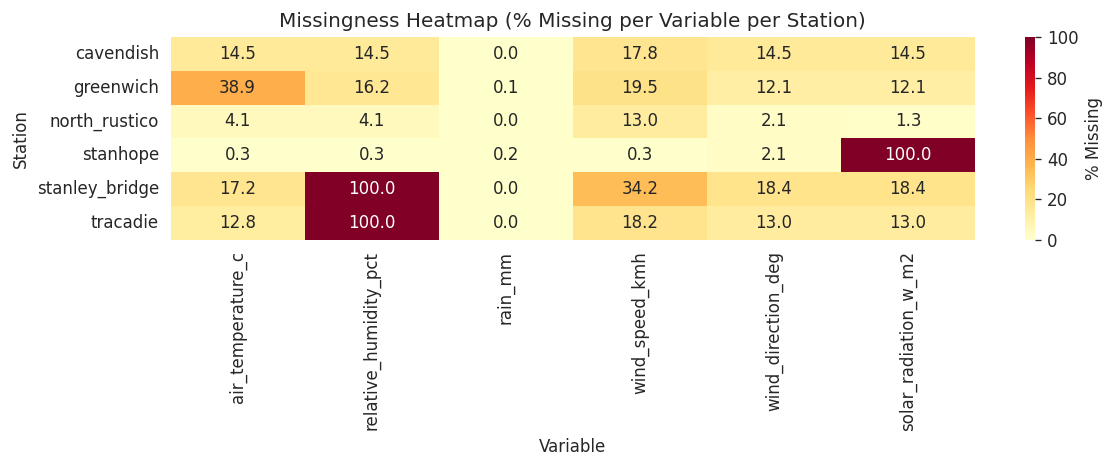

Saved: notebooks/figures/missingness_heatmap.png

Missingness summary:
                air_temperature_c  relative_humidity_pct  rain_mm  wind_speed_kmh  wind_direction_deg  solar_radiation_w_m2
station                                                                                                                    
cavendish                    14.5                   14.5      0.0            17.8                14.5                  14.5
greenwich                    38.9                   16.2      0.1            19.5                12.1                  12.1
north_rustico                 4.1                    4.1      0.0            13.0                 2.1                   1.3
stanhope                      0.3                    0.3      0.2             0.3                 2.1                 100.0
stanley_bridge               17.2                  100.0      0.0            34.2                18.4                  18.4
tracadie                     12.8                  100.0     

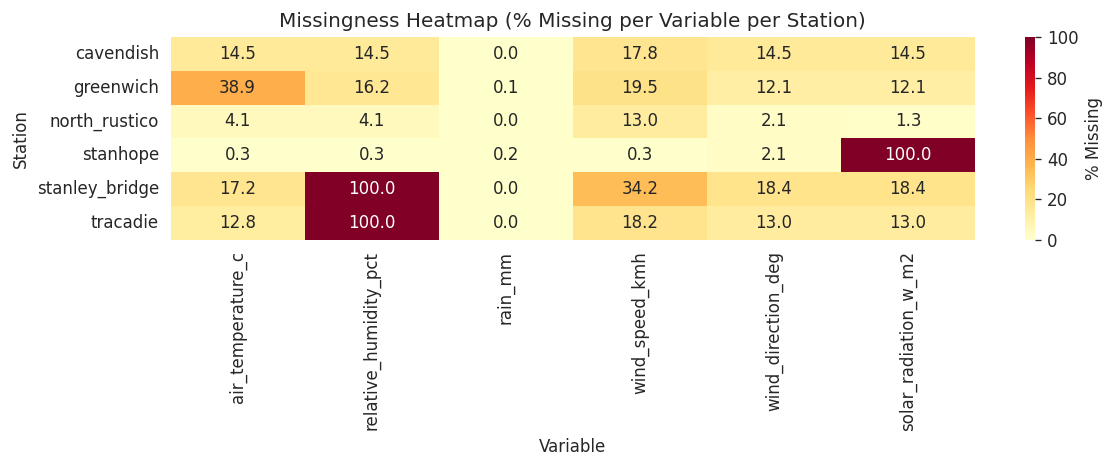

In [5]:
key_vars = [
    "air_temperature_c", "relative_humidity_pct", "rain_mm",
    "wind_speed_kmh", "wind_direction_deg", "solar_radiation_w_m2",
]

missing_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath)
    df = df[pd.to_datetime(df["timestamp_utc"], utc=True) >= ANALYSIS_START]
    row = {"station": station}
    for var in key_vars:
        if var in df.columns:
            row[var] = df[var].isna().mean() * 100
        else:
            row[var] = 100.0
    missing_frames.append(row)

missing_df = pd.DataFrame(missing_frames).set_index("station")
missing_df = missing_df[key_vars]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    missing_df, annot=True, fmt=".1f", cmap="YlOrRd",
    ax=ax, cbar_kws={"label": "% Missing"},
)
ax.set_title("Missingness Heatmap (% Missing per Variable per Station)")
ax.set_xlabel("Variable")
ax.set_ylabel("Station")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "missingness_heatmap.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "missingness_heatmap.png")))
print("Saved: notebooks/figures/missingness_heatmap.png")
print("\nMissingness summary:")
print(missing_df.round(1).to_string())


## 3. Fire Weather Index Analysis

Time series of FWI system components for stations with computed indices.


In [6]:
fwi_stations = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "fwi" in df.columns and df["fwi"].notna().sum() > 100:
        fwi_stations.append(station)

print(f"Stations with FWI data: {fwi_stations}")


Stations with FWI data: ['cavendish', 'greenwich', 'north_rustico', 'stanhope']


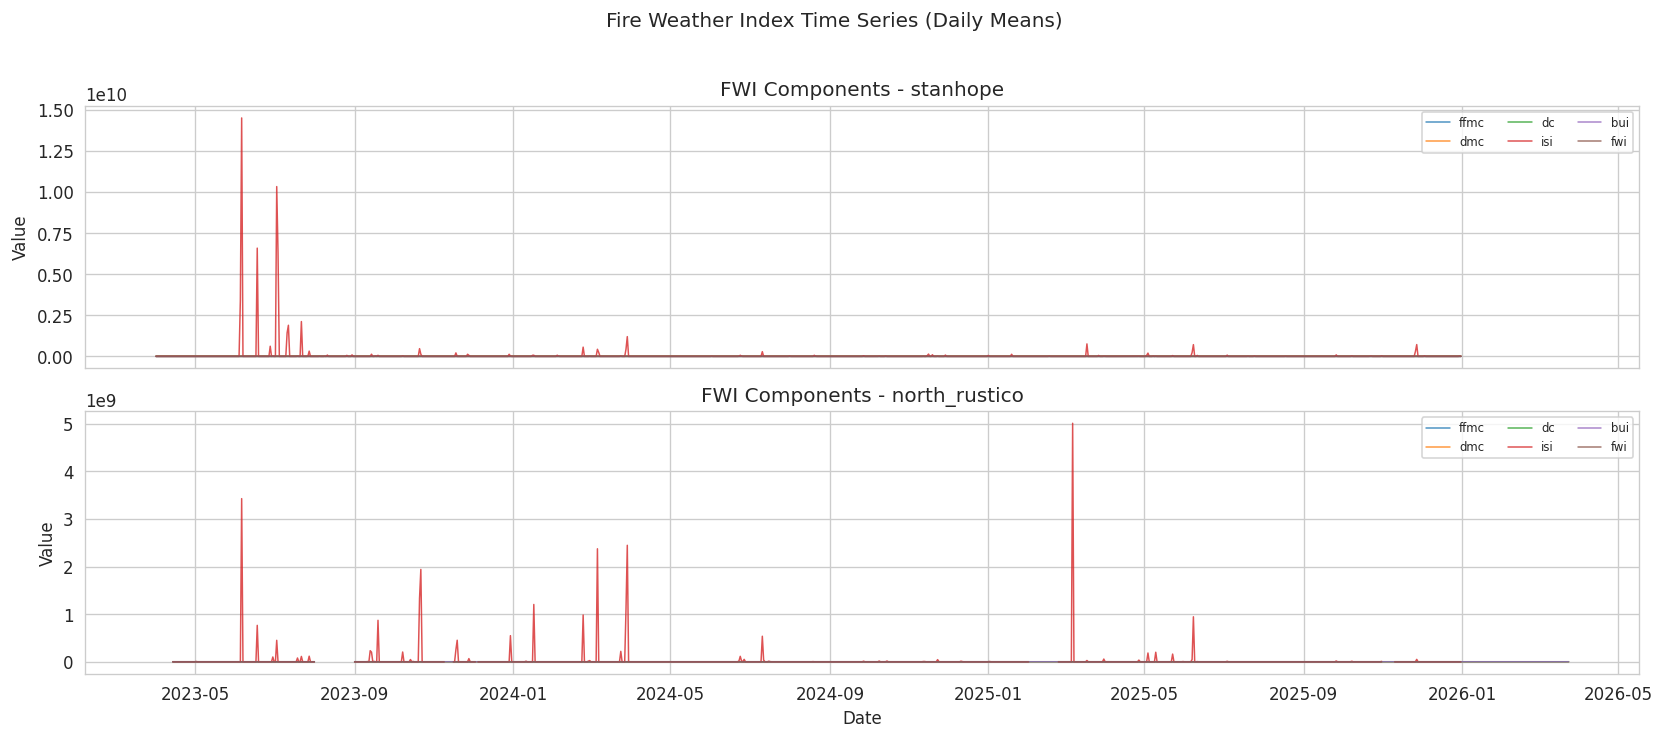

Plotted FWI for: ['stanhope', 'north_rustico']
Saved: notebooks/figures/fwi_timeseries.png


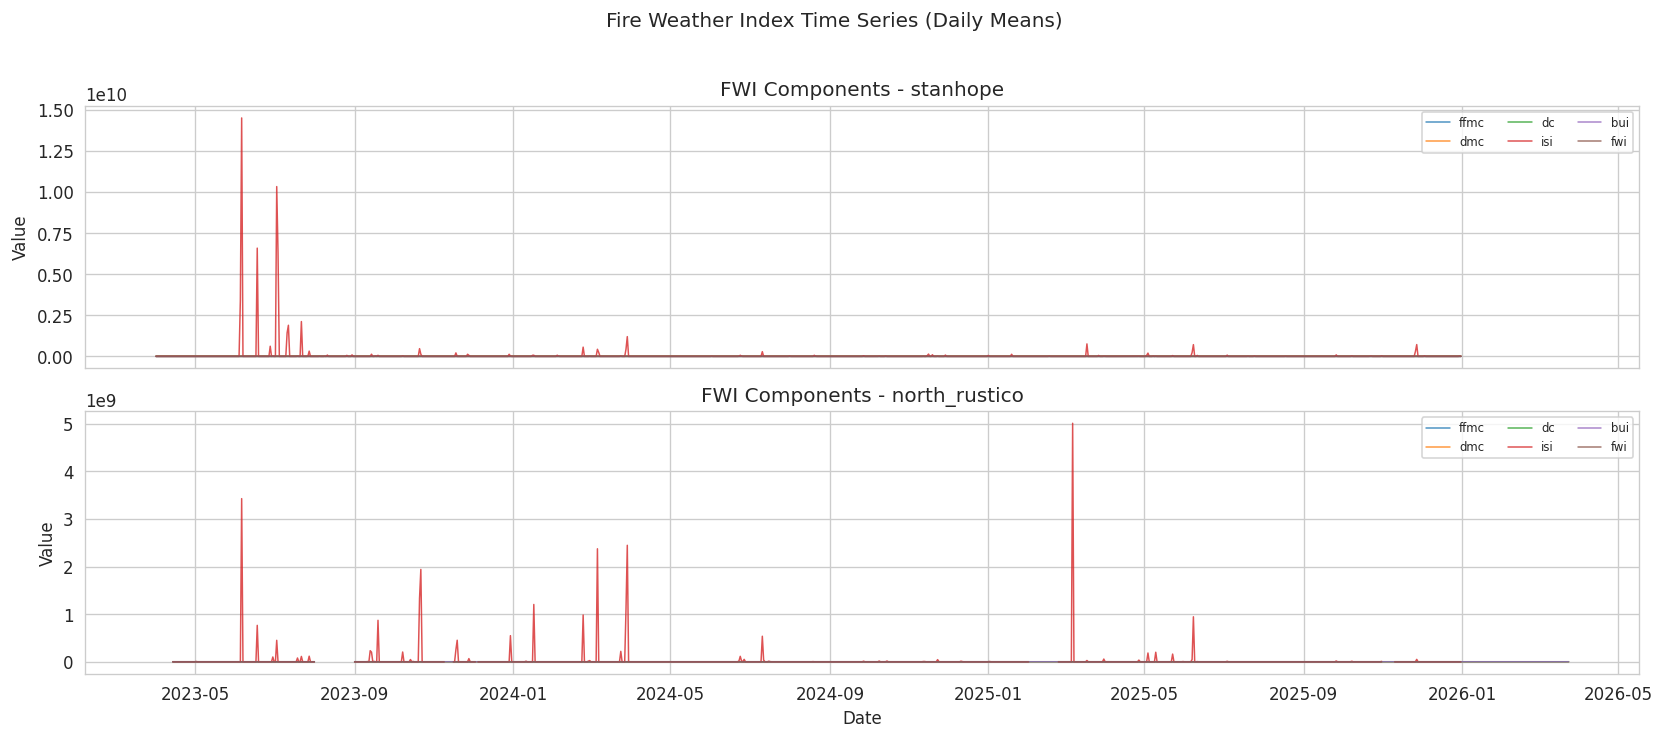

In [7]:
fwi_vars = ["ffmc", "dmc", "dc", "isi", "bui", "fwi"]

# Sort by available FWI records descending
fwi_sorted = sorted(
    fwi_stations,
    key=lambda s: pd.read_csv(
        PROCESSED_DIR / s / "station_hourly.csv",
        parse_dates=["timestamp_utc"],
    )["fwi"].notna().sum(),
    reverse=True,
)
plot_stations = fwi_sorted[: min(2, len(fwi_sorted))]

fig, axes = plt.subplots(
    len(plot_stations), 1,
    figsize=(14, 3 * len(plot_stations)),
    sharex=True,
)
if len(plot_stations) == 1:
    axes = [axes]

for idx, station in enumerate(plot_stations):
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    df_daily = (
        df.set_index("timestamp_utc")[fwi_vars].resample("D").mean()
    )
    ax = axes[idx]
    for var in fwi_vars:
        if var in df_daily.columns:
            ax.plot(
                df_daily.index, df_daily[var],
                label=var, alpha=0.8, linewidth=0.9,
            )
    ax.set_ylabel("Value")
    ax.set_title(f"FWI Components - {station}")
    ax.legend(fontsize=7, ncol=3)

axes[-1].set_xlabel("Date")
fig.suptitle(
    "Fire Weather Index Time Series (Daily Means)", y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fwi_timeseries.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "fwi_timeseries.png")))
print(f"Plotted FWI for: {plot_stations}")
print("Saved: notebooks/figures/fwi_timeseries.png")


## 4. Principal Component Analysis

PCA on hourly temperature to identify station similarity patterns.


In [8]:
temp_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "air_temperature_c" in df.columns:
        temp_frames.append(
            df[["station", "timestamp_utc", "air_temperature_c"]]
        )

temp_all = pd.concat(temp_frames, ignore_index=True)
matrix = build_station_matrix(temp_all, value_column="air_temperature_c")
print(f"Station matrix shape: {matrix.shape}")
print(f"Stations: {list(matrix.columns)}")


Station matrix shape: (26113, 6)
Stations: ['cavendish', 'greenwich', 'north_rustico', 'stanhope', 'stanley_bridge', 'tracadie']


In [9]:
loadings = pca_station_loadings(matrix)
print("PCA Loadings:")
print(loadings.to_string(index=False))


PCA Loadings:
       station component   loading  explained_variance_ratio
     cavendish       PC1  0.415556                  0.953981
     greenwich       PC1  0.391735                  0.953981
 north_rustico       PC1  0.415221                  0.953981
      stanhope       PC1  0.407649                  0.953981
stanley_bridge       PC1  0.403548                  0.953981
      tracadie       PC1  0.415235                  0.953981
     cavendish       PC2 -0.142397                  0.024147
     greenwich       PC2  0.913420                  0.024147
 north_rustico       PC2 -0.142898                  0.024147
      stanhope       PC2 -0.186853                  0.024147
stanley_bridge       PC2 -0.270443                  0.024147
      tracadie       PC2 -0.130054                  0.024147


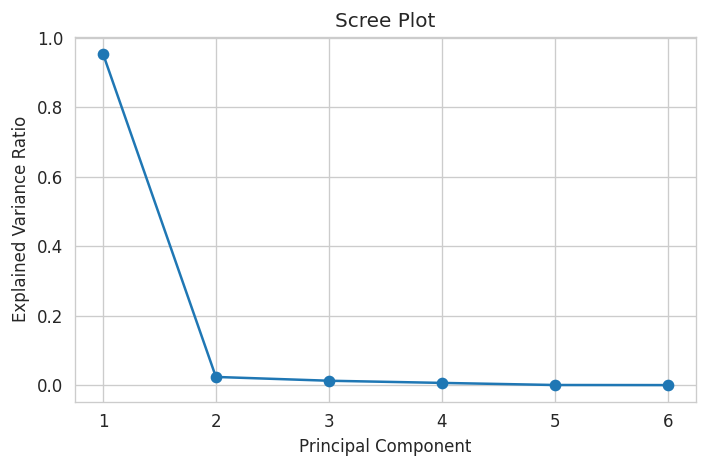

Saved: notebooks/figures/pca_scree.png
Explained variance ratios: [0.954, 0.0241, 0.0132, 0.007, 0.001, 0.0007]


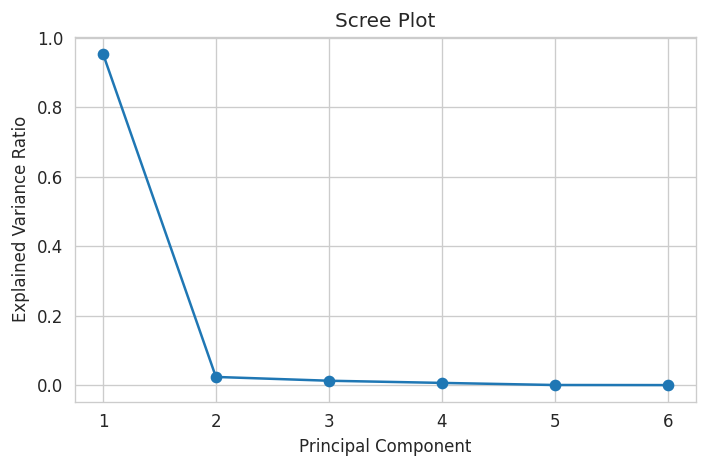

In [10]:
normalized = matrix.dropna(axis="index", how="any")
normalized = (normalized - normalized.mean()) / normalized.std()

n_comp = min(len(matrix.columns), normalized.shape[0])
pca_full = PCA(n_components=n_comp)
pca_full.fit(normalized)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, n_comp + 1), pca_full.explained_variance_ratio_, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot")
ax.set_xticks(range(1, n_comp + 1))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_scree.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "pca_scree.png")))
print("Saved: notebooks/figures/pca_scree.png")
ratios = pca_full.explained_variance_ratio_.round(4).tolist()
print(f"Explained variance ratios: {ratios}")


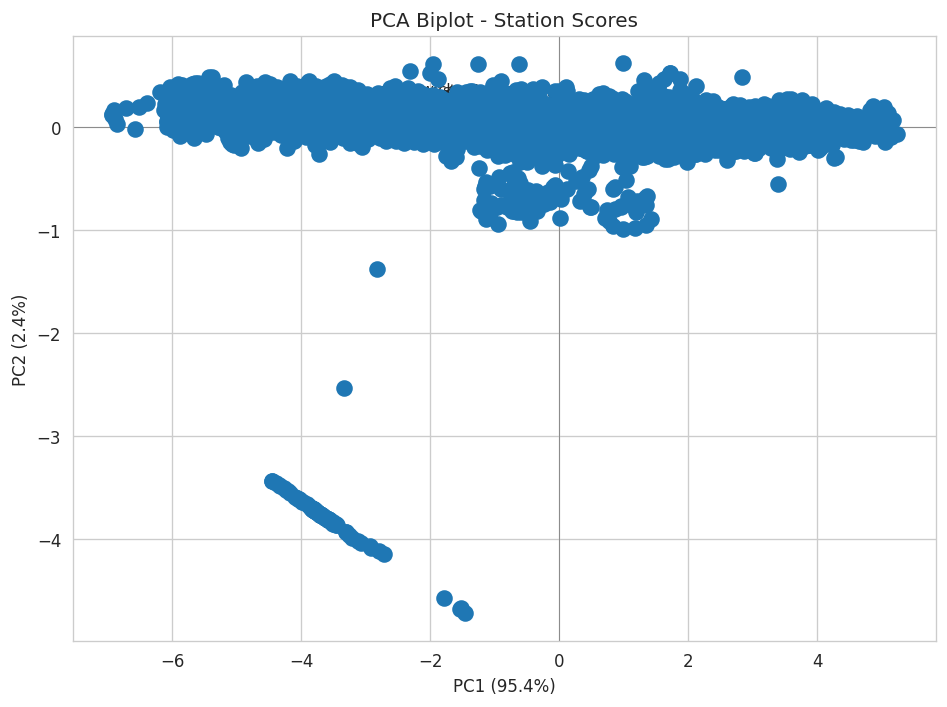

Saved: notebooks/figures/pca_biplot.png


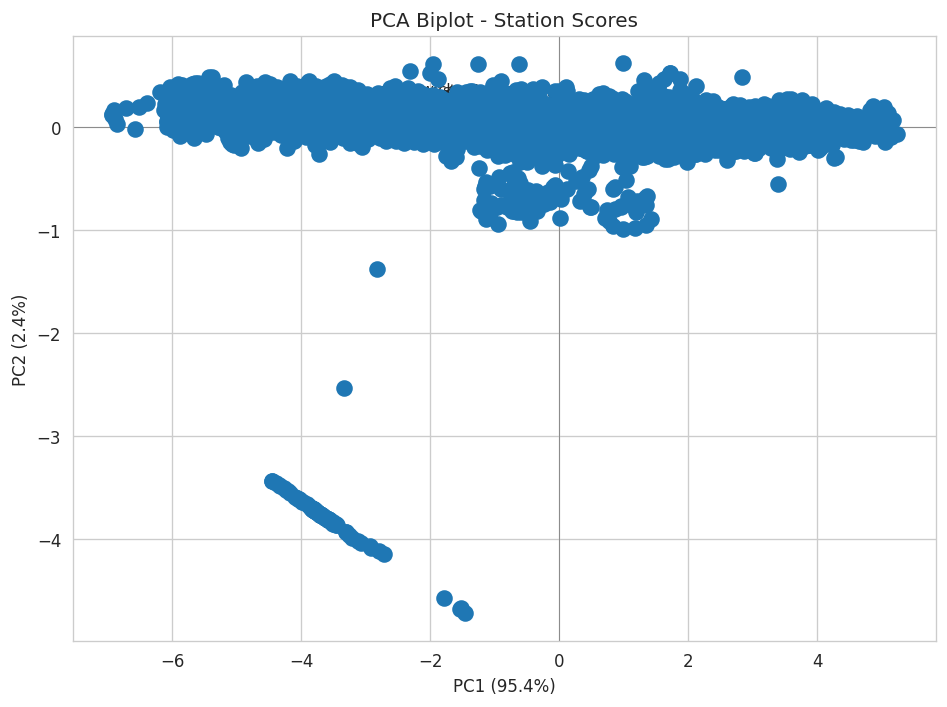

In [11]:
scores = pca_full.transform(normalized)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scores[:, 0], scores[:, 1], s=80, zorder=5)
for i, station in enumerate(matrix.columns):
    ax.annotate(
        station, (scores[i, 0], scores[i, 1]),
        textcoords="offset points", xytext=(5, 5), fontsize=9,
    )
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA Biplot - Station Scores")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_biplot.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "pca_biplot.png")))
print("Saved: notebooks/figures/pca_biplot.png")


## 5. Hierarchical Clustering

Stations clustered by temperature correlation to identify redundancy groups.


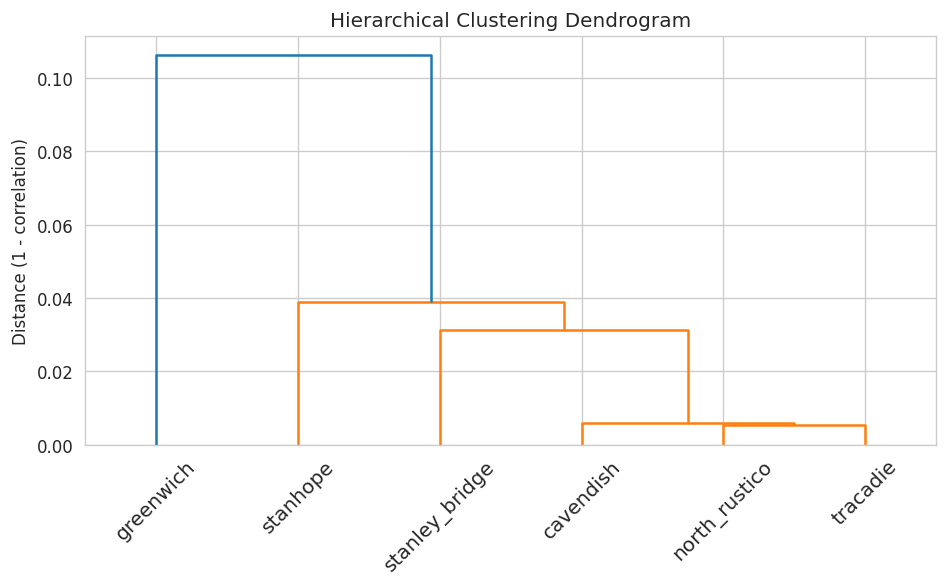

Saved: notebooks/figures/clustering_dendrogram.png


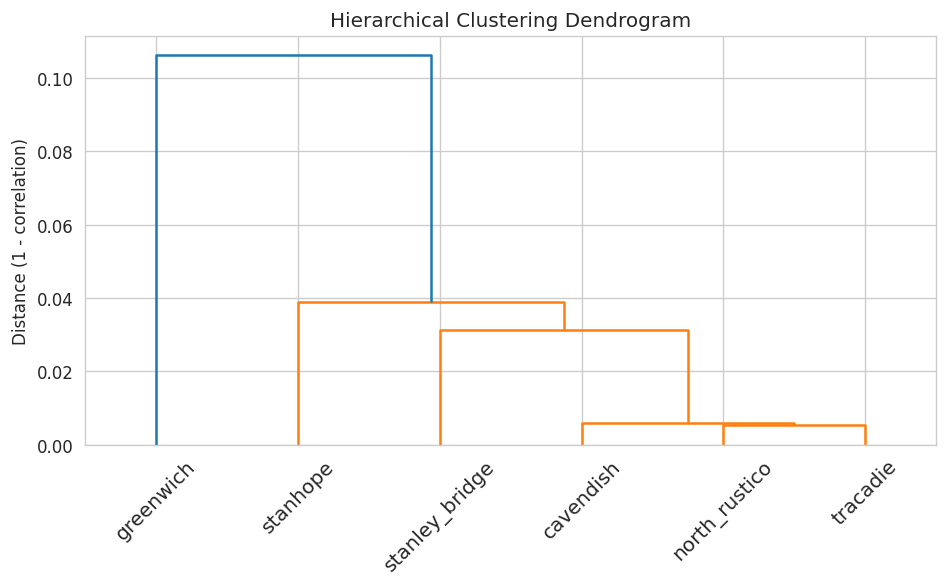

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

corr = matrix.corr()
distance = 1 - corr
dist_array = squareform(distance.values, checks=False)

link = linkage(dist_array, method="average")

fig, ax = plt.subplots(figsize=(8, 5))
dendrogram(link, labels=list(matrix.columns), ax=ax, leaf_rotation=45)
ax.set_ylabel("Distance (1 - correlation)")
ax.set_title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clustering_dendrogram.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / "clustering_dendrogram.png")))
print("Saved: notebooks/figures/clustering_dendrogram.png")


In [13]:
cluster_order = cluster_station_order(matrix)
print("Cluster assignments:")
for entry in cluster_order:
    print(f"  {entry}")

corr = pairwise_station_correlation(matrix).fillna(0.0)
dist = 1 - corr
print("\nPairwise distance matrix:")
print(dist.round(3).to_string())


Cluster assignments:
  stanhope
  tracadie
  cavendish
  north_rustico
  stanley_bridge
  greenwich

Pairwise distance matrix:
station         cavendish  greenwich  north_rustico  stanhope  stanley_bridge  tracadie
station                                                                                
cavendish           0.000      0.115          0.006     0.033           0.031     0.006
greenwich           0.115      0.000          0.101     0.133           0.105     0.077
north_rustico       0.006      0.101          0.000     0.035           0.031     0.005
stanhope            0.033      0.133          0.035     0.000           0.058     0.030
stanley_bridge      0.031      0.105          0.031     0.058           0.000     0.032
tracadie            0.006      0.077          0.005     0.030           0.032     0.000


## 6. Redundancy Analysis

Combining PCA, clustering, and benchmarking against the Stanhope reference
to identify redundant stations.


In [14]:
try:
    benchmark = benchmark_to_stanhope(
        matrix, reference_station="stanhope",
    )
    print("Benchmark results:")
    print(benchmark.to_string(index=False))
except ValueError as e:
    print(f"Stanhope benchmark skipped: {e}")
    print("Using inter-station metrics only.")
    benchmark = None


Benchmark results:
       station reference_station  overlap_count  mean_abs_diff  correlation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [15]:
if benchmark is not None and len(benchmark) > 0:
    recommendations = build_station_recommendations(
        benchmark,
        pca_loadings=loadings,
        cluster_order=cluster_order,
    )
    print("Station Recommendations:")
    print(recommendations.to_string(index=False))
else:
    print("Cannot build recommendations without benchmark.")
    recommendations = None


Station Recommendations:
       station reference_station recommendation  risk_probability  ci_lower  ci_upper risk_band                                                                                                    evidence                                                                                                                                                                                                                                                                                  assumptions                                                limitations
     cavendish          stanhope         remove          0.121140  0.012887  0.288408       low benchmark correlation=0.967; uncertainty=low (0.01-0.29); pca=[PC1=0.416, PC2=-0.142]; cluster=position 3/6 Distributional uncertainty is estimated with scipy.stats.gaussian_kde over observation-derived station-reference divergence samples; when benchmark fixtures omit raw observations, a documented synthetic distribution is gene

## 7. Uncertainty Quantification

Risk probabilities and confidence intervals for station removal.


Uncertainty Quantification (KDE-based risk):
       station reference_station  risk_probability  ci_lower  ci_upper risk_band                                                                                                                                                                                                                                                                                  assumptions                                                limitations
     cavendish          stanhope          0.121140  0.012887  0.288408       low Distributional uncertainty is estimated with scipy.stats.gaussian_kde over observation-derived station-reference divergence samples; when benchmark fixtures omit raw observations, a documented synthetic distribution is generated from mean difference, correlation, and overlap support. Sample support is adequate for a coarse uncertainty bound.
     greenwich          stanhope          0.046798  0.000376  0.079601       low Distributional uncertain

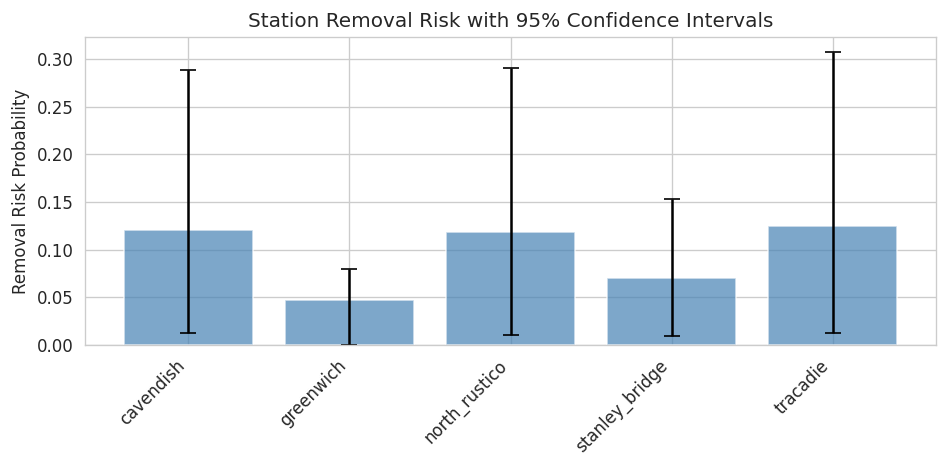

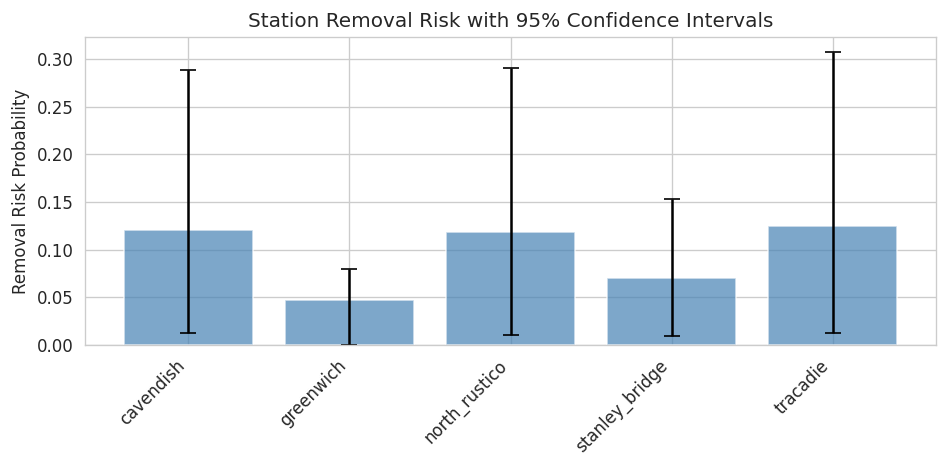

Saved: notebooks/figures/uncertainty_risk.png


In [16]:
from pea_met_network.uncertainty import quantify_station_removal_risk

if benchmark is not None and len(benchmark) > 0:
    uncertainty = quantify_station_removal_risk(benchmark)
    print("Uncertainty Quantification (KDE-based risk):")
    print(uncertainty.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    stations_plot = uncertainty["station"].tolist()
    risks = uncertainty["risk_probability"].tolist()
    ci_lo = uncertainty["ci_lower"].tolist()
    ci_hi = uncertainty["ci_upper"].tolist()

    x = range(len(stations_plot))
    ax.bar(x, risks, color="steelblue", alpha=0.7)
    yerr_lo = [r - lo for r, lo in zip(risks, ci_lo)]
    yerr_hi = [hi - r for r, hi in zip(risks, ci_hi)]
    ax.errorbar(
        x, risks, yerr=[yerr_lo, yerr_hi],
        fmt="none", c="black", capsize=5,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(stations_plot, rotation=45, ha="right")
    ax.set_ylabel("Removal Risk Probability")
    ax.set_title(
        "Station Removal Risk with 95% Confidence Intervals",
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "uncertainty_risk.png", bbox_inches="tight")
    plt.show()
    display(Image(filename=str(FIGURES_DIR / "uncertainty_risk.png")))
    print("Saved: notebooks/figures/uncertainty_risk.png")
else:
    print("Uncertainty analysis requires benchmark data (skipped).")


## 8. Conclusion

### Key Findings

1. **Data Coverage**: 

2. **Data Quality**:.

3. **Fire Weather Index**: 

4. **Station Redundancy**: 

5. **Redundancy Recommendations**: 

### Recommendations

